# Imports & Paths

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", os.environ.get("NUMBER_OF_PROCESSORS", "1"))

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "cnt_project").exists():
            return p
    raise RuntimeError("Could not locate project root containing src/cnt_project")

PROJECT_ROOT = _find_project_root(Path.cwd())

PROJECT_SRC_ROOT = PROJECT_ROOT / "src"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks" / "paper_figures"
LEGACY_NOTEBOOK_ROOT = PROJECT_ROOT / "testing" / "Notebooks" / "Paper_figures"

for p in [str(PROJECT_SRC_ROOT), str(NOTEBOOK_ROOT), str(LEGACY_NOTEBOOK_ROOT)]:
    if p in sys.path:
        sys.path.remove(p)

# Main project package: cnt_project.*
sys.path.insert(0, str(PROJECT_SRC_ROOT))

# Current notebook helper package: src.*
sys.path.insert(0, str(NOTEBOOK_ROOT))

# Legacy helpers only as fallback.
sys.path.insert(1, str(LEGACY_NOTEBOOK_ROOT))

from cnt_project.io.paths import ProjectPaths
from src.data.confusion_metrics import load_confusion_metrics
from src.utils.constants import AP2_COLOR_MAP, FIG_SIZES
from src.utils.paths import OUTPUTS

from cnt_project.visualizations.experiments.paper_figures.ap_iou_curves import (
    plot_ap_iou_curves,
)

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import scienceplots

plt.style.use(["science", "no-latex"])

P = ProjectPaths.from_here(PROJECT_ROOT / "src" / "cnt_project" / "io" / "paths.py")
print(f"Using runs root: {P.runs_root}")

Using runs root: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs


# Load Data

In [2]:
metric_file = "dsb_per_image_threshold_metrics.csv"

COMPARISON_LEGEND_ORDER = ["NanoVision", "MaskRCNN", "WormSwin"]

OLD_RUNS = ["fluo_new_edt", "detectron2_trial_1", "wormswin"]
OLD_RUN_NAME_MAP = {
    "fluo_new_edt": "NanoVision",
    "detectron2_trial_1": "MaskRCNN",
    "wormswin": "WormSwin",
}

NEW_RUNS = [
    "fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004",
    "detectron2_trial_1_LB_legacy_recheck",
    "wormswin_20260610",
]
NEW_RUN_NAME_MAP = {
    "fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004": "NanoVision",
    "detectron2_trial_1_LB_legacy_recheck": "MaskRCNN",
    "wormswin_20260610": "WormSwin",
}

old_conf_df = load_confusion_metrics(
    model_names=OLD_RUNS,
    project_paths=P,
    metric_file=metric_file,
    metric_subpath="eval/dsb/Diagnostic_eval__gt-old__pred-poly/dsb_per_image_threshold_metrics.csv",
    require_metric_subpath=True,
    legacy_metric_candidates=(),
)
old_conf_df["experiment"] = old_conf_df["experiment"].map(lambda x: OLD_RUN_NAME_MAP.get(x, x))
old_conf_df = old_conf_df[old_conf_df["experiment"].isin(COMPARISON_LEGEND_ORDER)].copy()

new_conf_df = load_confusion_metrics(
    model_names=NEW_RUNS,
    project_paths=P,
    metric_file=metric_file,
    metric_subpath="eval/dsb/Diagnostic_eval__gt-chain_none__pred-poly/dsb_per_image_threshold_metrics.csv",
    require_metric_subpath=True,
    legacy_metric_candidates=(),
)
new_conf_df["experiment"] = new_conf_df["experiment"].map(lambda x: NEW_RUN_NAME_MAP.get(x, x))
new_conf_df = new_conf_df[new_conf_df["experiment"].isin(COMPARISON_LEGEND_ORDER)].copy()

print("Old runs counts:")
print(old_conf_df["experiment"].value_counts(dropna=False))
print("\nNew runs counts:")
print(new_conf_df["experiment"].value_counts(dropna=False))

Old runs counts:
experiment
NanoVision    600
MaskRCNN      600
WormSwin      560
Name: count, dtype: int64

New runs counts:
experiment
NanoVision    300
MaskRCNN      300
WormSwin      300
Name: count, dtype: int64


# AP vs IoU: What Each Figure Means

This section intentionally shows two AP families for both old and new runs.

1. Classical precision AP-style curves (`precision = TP / (TP + FP)`)
- `macro`: mean per-image precision at each IoU threshold.
- `mean_counts`: precision computed from mean TP/FP counts.
- These curves tell us how object precision changes with IoU using the classical precision definition.

2. DSB AP curves (`dsb_precision = TP / (TP + FP + FN)`)
- `macro`: mean per-image DSB precision at each IoU threshold.
- `mean_counts`: DSB precision computed from mean TP/FP/FN counts.
- These curves align with the DSB AP metric used in the full-dataset run metrics summary notebook.

At the end, two tables summarize AP at IoU 0.05 for both definitions and both averaging modes.


Plotting old runs: classical precision AP (macro)...


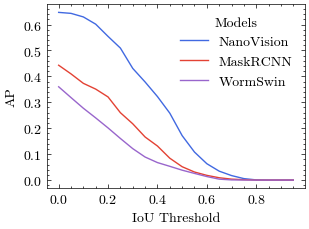

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\ap_vs_iou_old_macro.svg
Plotting old runs: classical precision AP (mean_counts)...


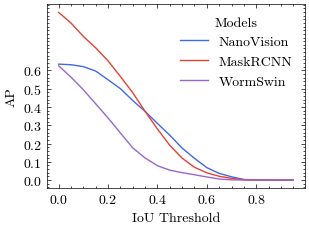

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\ap_vs_iou_old_mean_counts.svg

Plotting new runs: classical precision AP (macro)...


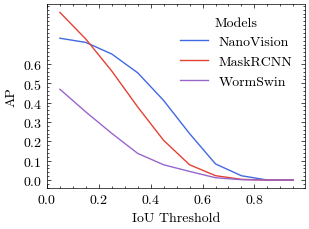

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\ap_vs_iou_new_macro.svg
Plotting new runs: classical precision AP (mean_counts)...


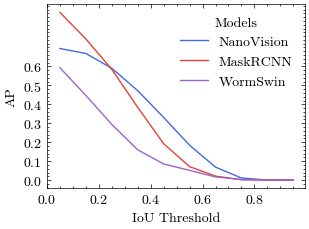

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\ap_vs_iou_new_mean_counts.svg

Plotting old runs: DSB AP (macro)...


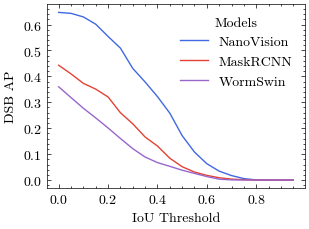

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\dsb_ap_vs_iou_old_macro.svg
Plotting old runs: DSB AP (mean_counts)...


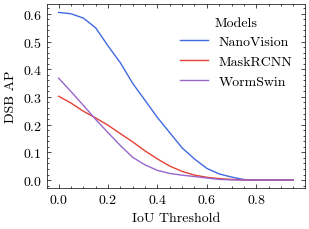

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\dsb_ap_vs_iou_old_mean_counts.svg

Plotting new runs: DSB AP (macro)...


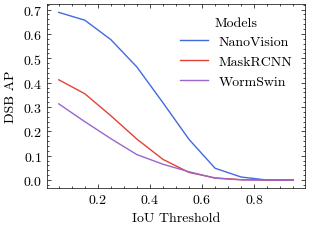

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\dsb_ap_vs_iou_new_macro.svg
Plotting new runs: DSB AP (mean_counts)...


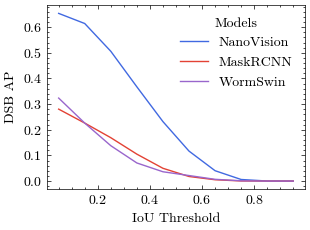

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\dsb_ap_vs_iou_new_mean_counts.svg

Classical precision AP @ IoU=0.05


,split,experiment,macro_ap_at_005,mean_counts_ap_at_005
0,new_runs,MaskRCNN,0.865984,0.885177
1,new_runs,NanoVision,0.732544,0.694466
2,new_runs,WormSwin,0.502509,0.592955
3,old_runs,MaskRCNN,0.844503,0.859081
4,old_runs,NanoVision,0.678222,0.631109
5,old_runs,WormSwin,0.480647,0.563112



DSB AP @ IoU=0.05


,split,experiment,macro_dsb_ap_at_005,mean_counts_dsb_ap_at_005
0,new_runs,MaskRCNN,0.411756,0.280609
1,new_runs,NanoVision,0.688505,0.653865
2,new_runs,WormSwin,0.312904,0.323718
3,old_runs,MaskRCNN,0.409577,0.277947
4,old_runs,NanoVision,0.642972,0.600089
5,old_runs,WormSwin,0.318224,0.319456


In [3]:
plot_jobs = [
    ("old", old_conf_df),
    ("new", new_conf_df),
]

# -----------------------------
# Figure set A: Classical precision AP-style
# -----------------------------
for tag, df_plot in plot_jobs:
    macro_path = OUTPUTS["scoring"] / f"ap_vs_iou_{tag}_macro.svg"
    mean_counts_path = OUTPUTS["scoring"] / f"ap_vs_iou_{tag}_mean_counts.svg"

    print(f"\nPlotting {tag} runs: classical precision AP (macro)...")
    plot_ap_iou_curves(
        df=df_plot,
        color_map=AP2_COLOR_MAP,
        legend_order=COMPARISON_LEGEND_ORDER,
        figsize=FIG_SIZES["double_half"],
        save_path=macro_path,
        average="macro",
    )
    print(f"Saved: {macro_path}")

    print(f"Plotting {tag} runs: classical precision AP (mean_counts)...")
    plot_ap_iou_curves(
        df=df_plot,
        color_map=AP2_COLOR_MAP,
        legend_order=COMPARISON_LEGEND_ORDER,
        figsize=FIG_SIZES["double_half"],
        save_path=mean_counts_path,
        average="mean_counts",
    )
    print(f"Saved: {mean_counts_path}")

# -----------------------------
# Figure set B: DSB AP curves
# -----------------------------
def plot_dsb_ap_iou_curves(
    df: pd.DataFrame,
    color_map: dict,
    legend_order: list[str],
    figsize=(3.3, 2.5),
    save_path=None,
    average: str = "macro",
):
    required = {"experiment", "IoU_thresh", "TP", "FP", "FN"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    if average == "macro":
        tmp = df.copy()
        if "dsb_precision" not in tmp.columns:
            tmp["dsb_precision"] = tmp["TP"] / (tmp["TP"] + tmp["FP"] + tmp["FN"])
        agg = (
            tmp.groupby(["experiment", "IoU_thresh"])["dsb_precision"]
            .mean()
            .reset_index(name="AP")
        )
    elif average == "mean_counts":
        agg_counts = (
            df.groupby(["experiment", "IoU_thresh"])[["TP", "FP", "FN"]]
            .mean()
            .reset_index()
        )
        agg_counts["AP"] = agg_counts["TP"] / (agg_counts["TP"] + agg_counts["FP"] + agg_counts["FN"])
        agg = agg_counts[["experiment", "IoU_thresh", "AP"]]
    else:
        raise ValueError("average must be one of: 'macro', 'mean_counts'")

    plt.figure(figsize=figsize)
    for exp in legend_order:
        sub = agg[agg["experiment"] == exp]
        if sub.empty:
            continue
        plt.plot(sub["IoU_thresh"], sub["AP"], label=exp, color=color_map.get(exp, "#000000"))

    plt.xlabel("IoU Threshold")
    plt.ylabel("DSB AP")
    ax = plt.gca()
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    plt.grid(False)
    plt.legend(title="Models", loc="upper right")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format="svg", bbox_inches="tight", pad_inches=0.02)
    plt.show()

for tag, df_plot in plot_jobs:
    dsb_macro_path = OUTPUTS["scoring"] / f"dsb_ap_vs_iou_{tag}_macro.svg"
    dsb_mean_counts_path = OUTPUTS["scoring"] / f"dsb_ap_vs_iou_{tag}_mean_counts.svg"

    print(f"\nPlotting {tag} runs: DSB AP (macro)...")
    plot_dsb_ap_iou_curves(
        df=df_plot,
        color_map=AP2_COLOR_MAP,
        legend_order=COMPARISON_LEGEND_ORDER,
        figsize=FIG_SIZES["double_half"],
        save_path=dsb_macro_path,
        average="macro",
    )
    print(f"Saved: {dsb_macro_path}")

    print(f"Plotting {tag} runs: DSB AP (mean_counts)...")
    plot_dsb_ap_iou_curves(
        df=df_plot,
        color_map=AP2_COLOR_MAP,
        legend_order=COMPARISON_LEGEND_ORDER,
        figsize=FIG_SIZES["double_half"],
        save_path=dsb_mean_counts_path,
        average="mean_counts",
    )
    print(f"Saved: {dsb_mean_counts_path}")

# -----------------------------
# IoU=0.05 summary tables
# -----------------------------
def summarize_ap_005(df_in: pd.DataFrame, split_name: str) -> pd.DataFrame:
    at_005 = df_in[df_in["IoU_thresh"] == 0.05].copy()

    at_005["precision_per_image"] = at_005["TP"] / (at_005["TP"] + at_005["FP"]).replace(0, pd.NA)
    macro_ap = (
        at_005.groupby("experiment", as_index=True)["precision_per_image"]
        .mean()
        .rename("macro_ap_at_005")
    )

    mean_counts_ap = (
        at_005.groupby("experiment")[["TP", "FP"]]
        .mean()
        .assign(mean_counts_ap_at_005=lambda d: d["TP"] / (d["TP"] + d["FP"]))["mean_counts_ap_at_005"]
    )

    out = pd.concat([macro_ap, mean_counts_ap], axis=1).reset_index()
    out["split"] = split_name
    return out

def summarize_dsb_ap_005(df_in: pd.DataFrame, split_name: str) -> pd.DataFrame:
    at_005 = df_in[df_in["IoU_thresh"] == 0.05].copy()

    if "dsb_precision" in at_005.columns:
        macro_dsb = (
            at_005.groupby("experiment", as_index=True)["dsb_precision"]
            .mean()
            .rename("macro_dsb_ap_at_005")
        )
    else:
        at_005["dsb_precision"] = at_005["TP"] / (at_005["TP"] + at_005["FP"] + at_005["FN"])
        macro_dsb = (
            at_005.groupby("experiment", as_index=True)["dsb_precision"]
            .mean()
            .rename("macro_dsb_ap_at_005")
        )

    mean_counts_dsb = (
        at_005.groupby("experiment")[["TP", "FP", "FN"]]
        .mean()
        .assign(
            mean_counts_dsb_ap_at_005=lambda d: d["TP"] / (d["TP"] + d["FP"] + d["FN"])
        )["mean_counts_dsb_ap_at_005"]
    )

    out = pd.concat([macro_dsb, mean_counts_dsb], axis=1).reset_index()
    out["split"] = split_name
    return out

ap_comparison_005 = pd.concat(
    [
        summarize_ap_005(old_conf_df, "old_runs"),
        summarize_ap_005(new_conf_df, "new_runs"),
    ],
    ignore_index=True,
)[["split", "experiment", "macro_ap_at_005", "mean_counts_ap_at_005"]]

dsb_ap_comparison_005 = pd.concat(
    [
        summarize_dsb_ap_005(old_conf_df, "old_runs"),
        summarize_dsb_ap_005(new_conf_df, "new_runs"),
    ],
    ignore_index=True,
)[["split", "experiment", "macro_dsb_ap_at_005", "mean_counts_dsb_ap_at_005"]]

ap_comparison_005 = ap_comparison_005.sort_values(["split", "experiment"]).reset_index(drop=True)
dsb_ap_comparison_005 = dsb_ap_comparison_005.sort_values(["split", "experiment"]).reset_index(drop=True)

print("\nClassical precision AP @ IoU=0.05")
display(ap_comparison_005.round(6))

print("\nDSB AP @ IoU=0.05")
display(dsb_ap_comparison_005.round(6))